In [13]:
import openeo

# Connect and authenticate
conn = openeo.connect("https://openeo.dataspace.copernicus.eu")
conn.authenticate_oidc()

# Define area of interest (bounding box)
bbox = {"west": 11.0, "south": 46.0, "east": 11.5, "north": 46.5}  # e.g. Trento area

# Load and filter data
cube = conn.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=bbox,
    temporal_extent=["2024-06-01", "2024-06-30"],
    bands=["B04", "B03", "B02"],  # RGB bands
    max_cloud_cover=20,
)

# Download
cube.download("sentinel2_trento.tiff")

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=AQHT-WVSW 📋 to authenticate.

[##############################-------] ⌛ Authorization pending

KeyboardInterrupt: 

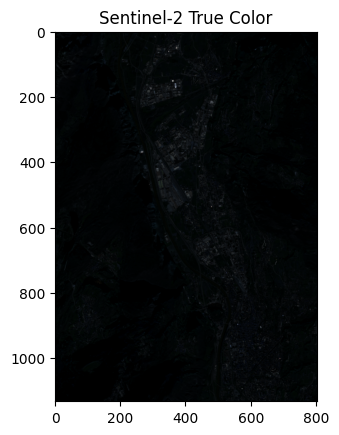

In [20]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open("sentinel2_multispectral_trento.tif") as src:
    rgb = src.read([1, 2, 3])  # Read RGB bands

# Normalize and display
rgb = np.moveaxis(rgb, 0, -1)
rgb = (rgb / rgb.max() * 255).astype(np.uint8)

plt.imshow(rgb)
plt.title("Sentinel-2 True Color")
plt.show()

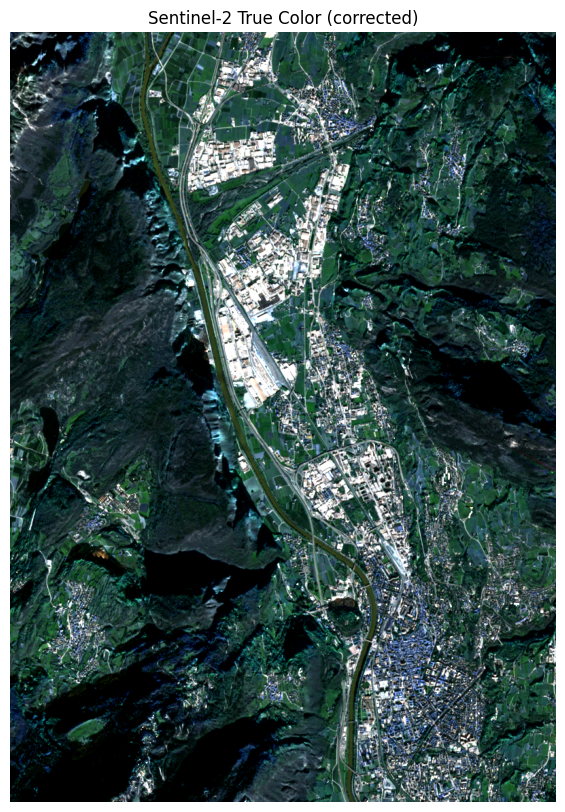

In [21]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def percentile_stretch(band, low=2, high=98):
    """Stretch band using percentile clipping to handle outliers."""
    lo, hi = np.percentile(band, low), np.percentile(band, high)
    stretched = (band - lo) / (hi - lo)
    return np.clip(stretched, 0, 1)

with rasterio.open("sentinel2_multispectral_trento.tif") as src:
    rgb = src.read([1, 2, 3]).astype(float)

# Stretch each band independently
r = percentile_stretch(rgb[0])
g = percentile_stretch(rgb[1])
b = percentile_stretch(rgb[2])

image = np.stack([r, g, b], axis=-1)

plt.figure(figsize=(8, 10))
plt.imshow(image)
plt.title("Sentinel-2 True Color (corrected)")
plt.axis("off")
plt.show()

In [22]:
with rasterio.open("sentinel2_multispectral_trento.tif") as src:
    print(src.count)        # total number of bands
    print(src.descriptions) # band names/dates if embedded
    print(src.meta)

11
(None, None, None, None, None, None, None, None, None, None, None)
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 803, 'height': 1133, 'count': 11, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32632"]]'), 'transform': Affine(10.0, 0.0, 658300.0,
       0.0, -10.0, 5112970.0)}


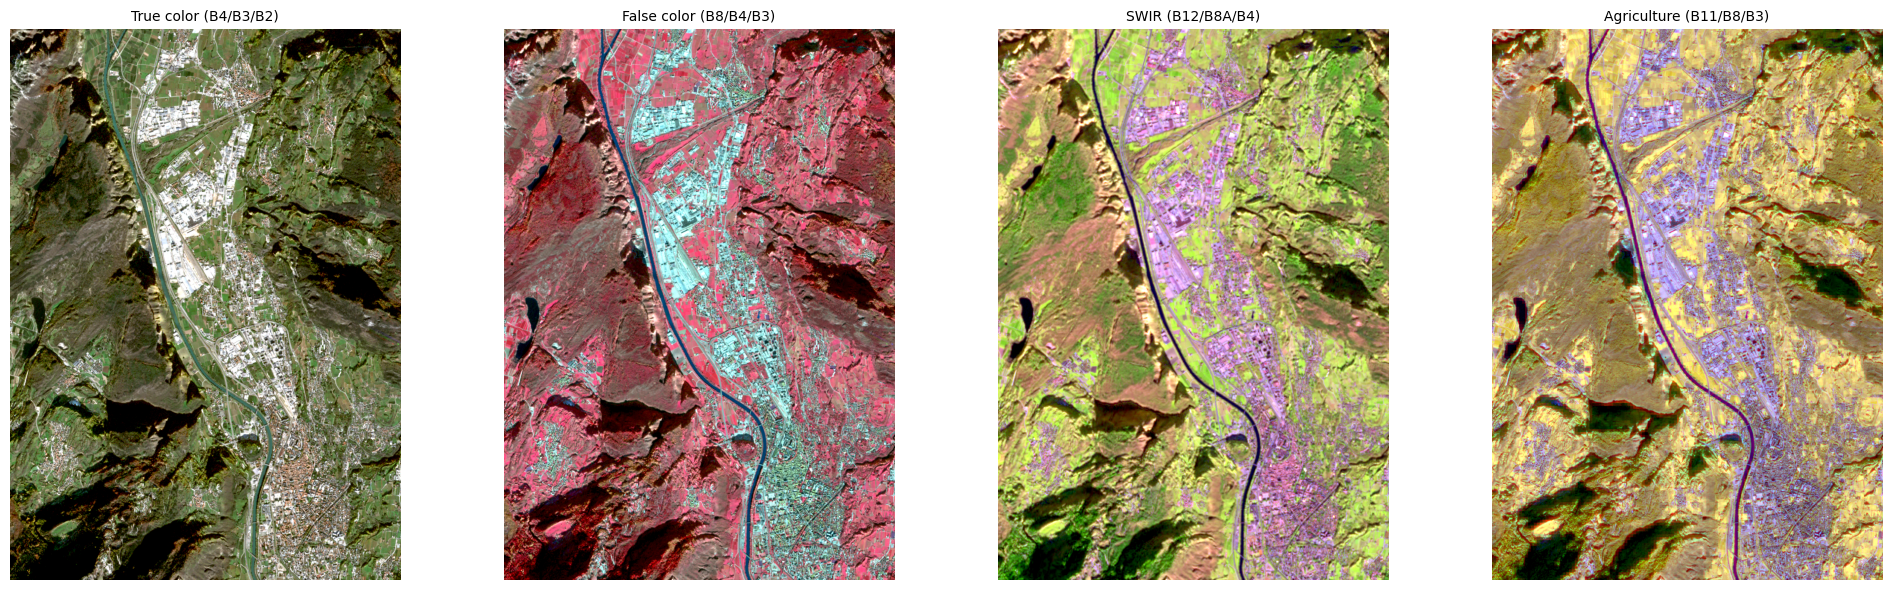

In [23]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def stretch(band, lo=2, hi=98):
    lo_val, hi_val = np.percentile(band[band > 0], lo), np.percentile(band[band > 0], hi)
    return np.clip((band.astype(float) - lo_val) / (hi_val - lo_val), 0, 1)

with rasterio.open("sentinel2_multispectral_trento.tif") as src:
    bands = src.read()  # shape: (11, 1133, 803)

# Band indices (0-based)
B2, B3, B4 = bands[0], bands[1], bands[2]   # Blue, Green, Red
B8 = bands[6]                                 # NIR
B11, B12 = bands[8], bands[9]                # SWIR1, SWIR2

composites = {
    "True color (B4/B3/B2)":     [B4, B3, B2],
    "False color (B8/B4/B3)":    [B8, B4, B3],   # vegetation = bright red
    "SWIR (B12/B8A/B4)":         [B12, bands[7], B4],  # fire/burn scars
    "Agriculture (B11/B8/B3)":   [B11, B8, B3],  # crop health
}

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for ax, (title, rgb_bands) in zip(axes, composites.items()):
    rgb = np.stack([stretch(b) for b in rgb_bands], axis=-1)
    rgb = np.power(rgb, 0.6)  # gamma
    ax.imshow(rgb)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("sentinel2_composites.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
import rasterio
import numpy as np

with rasterio.open("sentinel2_multispectral_trento.tif") as src:
    print("Total bands:", src.count)
    print("Descriptions:", src.descriptions)
    print("Tags:", src.tags())
    
    # Check if band stats look like a single date or a composite
    for i in range(1, src.count + 1):
        b = src.read(i).astype(float)
        b_valid = b[b > 0]
        print(f"Band {i}: min={b_valid.min():.0f}, max={b_valid.max():.0f}, "
              f"mean={b_valid.mean():.0f}, zeros={np.sum(b==0)}")

Total bands: 11
Descriptions: (None, None, None, None, None, None, None, None, None, None, None)
Tags: {'AREA_OR_POINT': 'Area'}
Band 1: min=1, max=17576, mean=233, zeros=193
Band 2: min=1, max=16664, mean=415, zeros=12
Band 3: min=1, max=16056, mean=465, zeros=8
Band 4: min=1, max=15817, mean=777, zeros=0
Band 5: min=1, max=15678, mean=1360, zeros=0
Band 6: min=1, max=15596, mean=1547, zeros=0
Band 7: min=1, max=15576, mean=1737, zeros=3
Band 8: min=1, max=15470, mean=1772, zeros=0
Band 9: min=1, max=6001, mean=1759, zeros=0
Band 10: min=1, max=15103, mean=1439, zeros=0
Band 11: min=1, max=15049, mean=944, zeros=0


In [19]:
from pystac_client import Client
from odc.stac import load
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Connect to AWS Earth Search (no auth needed) ──────────────────────────
client = Client.open("https://earth-search.aws.element84.com/v1")

# ── 2. Define your search ────────────────────────────────────────────────────
bbox = [11.05, 46.05, 11.15, 46.15]  # lon_min, lat_min, lon_max, lat_max (Trento area)

search = client.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2024-06-01/2025-08-31",
    query={"eo:cloud_cover": {"lt": 10}},  # < 10% cloud cover
)

items = list(search.items())
print(f"Found {len(items)} scenes")

# ── 3. Load all multispectral bands into xarray ──────────────────────────────
# Sentinel-2 L2A bands available:
# B01(coastal), B02(blue), B03(green), B04(red),
# B05(red edge1), B06(red edge2), B07(red edge3),
# B08(NIR), B8A(NIR narrow), B09(water vapor),
# B11(SWIR1), B12(SWIR2), SCL(scene classification)

bands = ["blue", "green", "red", "rededge1", "rededge2", "rededge3",
         "nir", "nir08", "nir09", "swir16", "swir22"]
ds = load(
    items,
    bands=bands,
    bbox=bbox,
    resolution=10,        # 10m resolution (use 20m for red-edge/SWIR bands)
    groupby="solar_day",  # one image per day, avoids duplicates
)

print(ds)  # xarray Dataset with all bands + timestamps

# ── 4. Pick best scene (least clouds) and save ───────────────────────────────
# Sort items by cloud cover and pick the best one
best = sorted(items, key=lambda x: x.properties["eo:cloud_cover"])[0]
print(f"Best scene: {best.id} — {best.properties['eo:cloud_cover']}% clouds")

# ── 5. Export as GeoTIFF (all bands stacked) ─────────────────────────────────
# Load single best scene
single = load(
    [best],
    bands=bands,
    bbox=bbox,
    resolution=10,
).isel(time=0)

# Save with rasterio
import rioxarray  # pip install rioxarray
stacked = single.to_array(dim="band")
stacked.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
stacked.rio.write_crs("EPSG:32632", inplace=True)  # UTM zone for Italy
stacked.rio.to_raster("sentinel2_multispectral_trento.tif")
print("Saved sentinel2_multispectral.tif")

# ── 6. Quick RGB preview ─────────────────────────────────────────────────────
rgb = np.dstack([
    single["B04"].values,  # Red
    single["B03"].values,  # Green
    single["B02"].values,  # Blue
]).astype(float)

# Normalize
p2, p98 = np.percentile(rgb, (2, 98))
rgb = np.clip((rgb - p2) / (p98 - p2), 0, 1)

plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.title(f"Sentinel-2 True Color\n{best.id}")
plt.axis("off")
plt.savefig("preview_rgb.png", dpi=150, bbox_inches="tight")
plt.show()

Found 35 scenes
<xarray.Dataset> Size: 661MB
Dimensions:      (y: 1133, x: 803, time: 33)
Coordinates:
  * y            (y) float64 9kB 5.113e+06 5.113e+06 ... 5.102e+06 5.102e+06
  * x            (x) float64 6kB 6.583e+05 6.583e+05 ... 6.663e+05 6.663e+05
    spatial_ref  int32 4B 32632
  * time         (time) datetime64[ns] 264B 2024-07-31T10:18:00.089000 ... 20...
Data variables:
    blue         (time, y, x) uint16 60MB 714 466 450 562 ... 193 205 222 271
    green        (time, y, x) uint16 60MB 1204 995 903 910 ... 357 357 381 500
    red          (time, y, x) uint16 60MB 1112 694 572 794 ... 289 255 284 330
    rededge1     (time, y, x) uint16 60MB 1611 1611 1483 1483 ... 739 739 958
    rededge2     (time, y, x) uint16 60MB 3335 3335 3001 3001 ... 1973 1973 2717
    rededge3     (time, y, x) uint16 60MB 3828 3828 3392 3392 ... 2399 2399 3204
    nir          (time, y, x) uint16 60MB 4253 4210 3848 4016 ... 1982 2246 3260
    nir08        (time, y, x) uint16 60MB 4289 4289 3840 

KeyError: "No variable named 'B04'. Variables on the dataset include ['y', 'x', 'spatial_ref', 'time', 'blue', ..., 'nir', 'nir08', 'nir09', 'swir16', 'swir22']"